In [1]:
# ============================================================
# CELL 0 – LOCAL ENVIRONMENT SETUP
# ============================================================
import os, sys

# Cấu trúc Local-first: lấy thư mục gốc của project
# Vì notebook nằm trong thư mục notebooks/, nên PROJECT_ROOT là thư mục cha.
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
REPO_PATH = PROJECT_ROOT

# Add src/ to Python path
if os.path.join(PROJECT_ROOT, 'src') not in sys.path:
    sys.path.insert(0, os.path.join(PROJECT_ROOT, 'src'))

print('✅ Local Environment ready. PROJECT_ROOT:', PROJECT_ROOT)


✅ Local Environment ready. PROJECT_ROOT: d:\000MINHTHONG\Junior - Semester II\ANLPB\FinalProject\hate-speech-detection


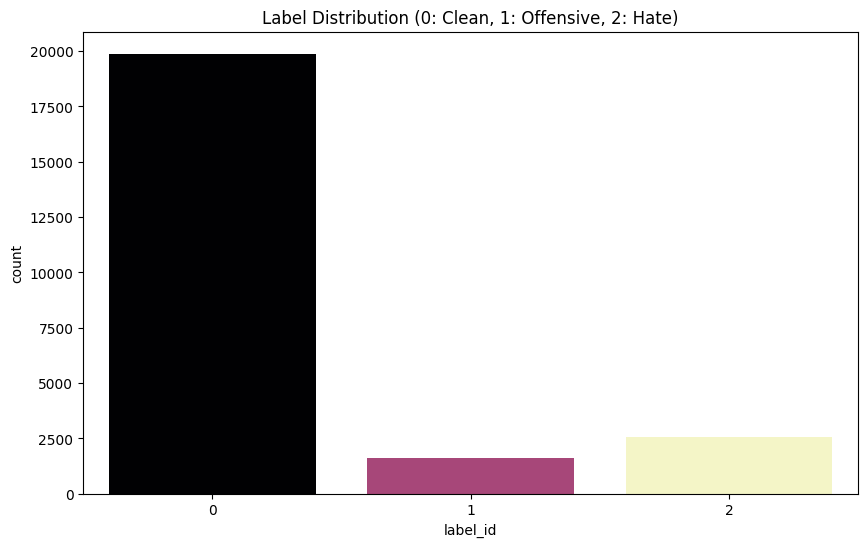

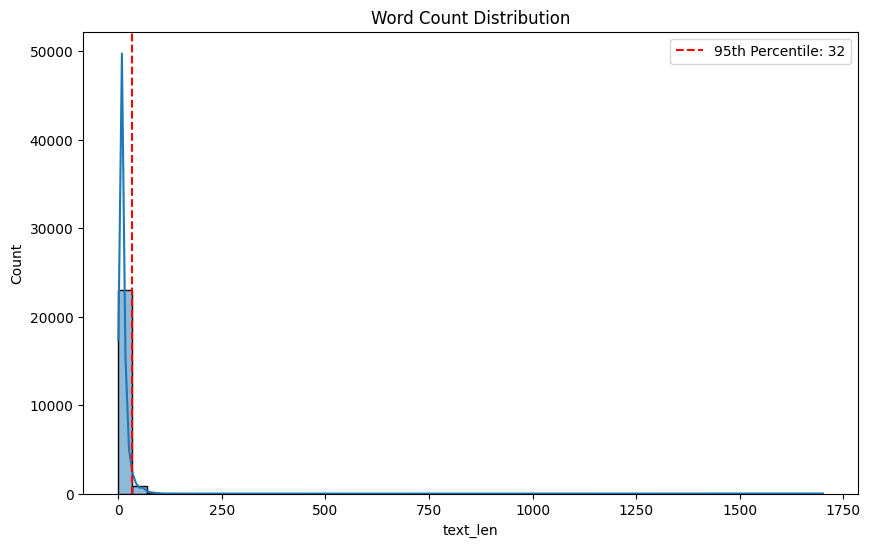

Decision: Recommended max_length is 32 words.


In [2]:
# ============================================================
# CELL 1 – LOAD DATA AND CONFIG
# ============================================================
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load paths from config
with open(f"{REPO_PATH}/configs/paths.yaml", 'r') as f:
    paths = yaml.safe_load(f)

# Path setup (Lưu ý: Bạn cần đảm bảo paths.yaml trỏ đúng vào data/raw/vihsd/)
train_path = os.path.join(PROJECT_ROOT, "data/raw/vihsd/train.csv")
train_df = pd.read_csv(train_path)

# 1. Label Distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='label_id', data=train_df, hue='label_id', palette='magma', legend=False)
plt.title('Label Distribution (0: Clean, 1: Offensive, 2: Hate)')
plt.savefig(f"{PROJECT_ROOT}/results/label_distribution.png")
plt.show()

# 2. Text Length Analysis (To decide max_length for Phase 5)
train_df['text_len'] = train_df['free_text'].fillna('').apply(lambda x: len(x.split()))
p95 = np.percentile(train_df['text_len'], 95)

plt.figure(figsize=(10, 6))
sns.histplot(train_df['text_len'], bins=50, kde=True)
plt.axvline(p95, color='r', linestyle='--', label=f'95th Percentile: {int(p95)}')
plt.title('Word Count Distribution')
plt.legend()
plt.savefig(f"{PROJECT_ROOT}/results/text_length_dist.png")
plt.show()

print(f"Decision: Recommended max_length is {int(p95)} words.")